**Task**  
Compare labels of different resolutions for overlap. This verifies consistency regardless of resolution. There should only ever be more precision, not different predictions, when resolution scale, assuming some margin of error.  
  
**Plan**  
Use 10m as a baseline. Scale down pixel size for higher resolutions. This can be done by performing an inverse scale mapping from the higher resolution image of larger pixel dimensions to the smaller image of lower resolution.

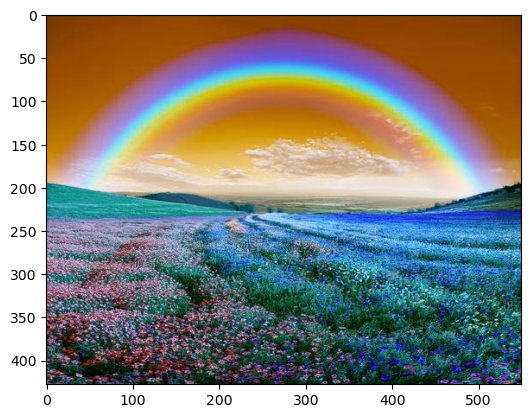

In [8]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(Path("images") / "rainbow_field.jpg")
plt.imshow(img);

In [9]:
(img > 240).sum()

np.int64(8553)

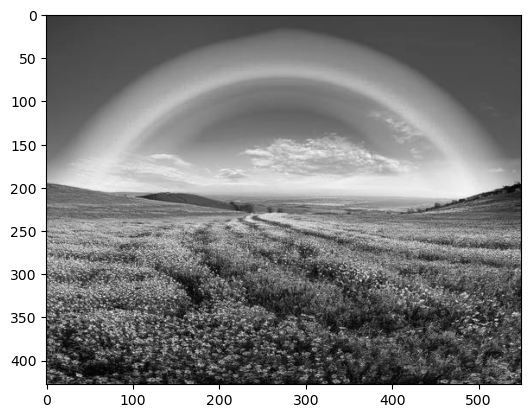

In [10]:
gimg = img.mean(axis=-1)
plt.imshow(gimg, cmap="gray")
plt.show()

count    235400.000000
mean        112.227700
std          52.548259
min           0.000000
25%          72.666667
50%         107.666667
75%         150.000000
max         249.000000
dtype: float64


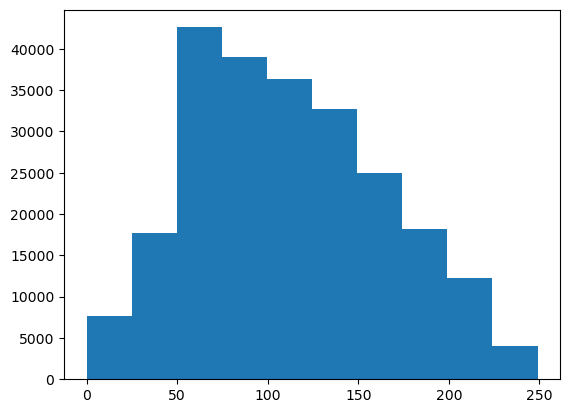

In [11]:
import pandas as pd

gdist = gimg.flatten()
print(pd.Series(gdist).describe())
plt.hist(gdist)
plt.show()

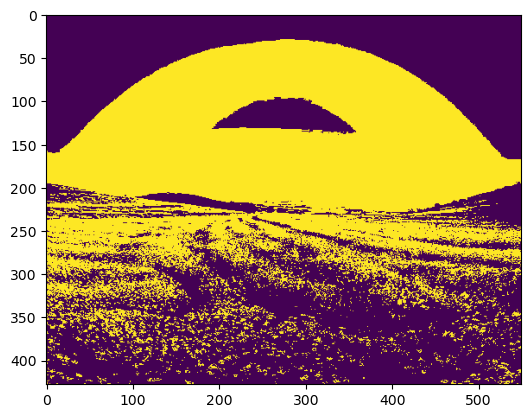

In [12]:
bimg = (gimg > gimg.mean()).astype(int)
plt.imshow(bimg)
plt.show()

(428, 550, 3) (2000, 1000, 3)


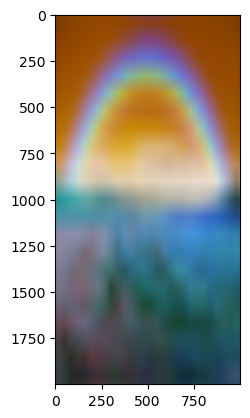

In [13]:
import skimage
import numpy as np

def scale_resolution_2d(img: np.ndarray, scale_factor: float, height: int, width: int):
    """
    Scales an image by a specified factor and distorts the image to the specified dimensions.

    Args:
        img: 2d np array. Expects the color channel to be the last argument. If using grayscale images, be sure that the last dimension has size 1.
        scale_factor: factor by which the scale the height and width of the image.
        height, width: dimensions of the output image

    Returns:
        rescaled: 2d np array with dimensions (height, width, color channels)
    """
    scale = [scale_factor for _ in range(len(img.shape))]
    scale[-1] = 1 # don't scale last dim. this changes the color scale used

    rescaled = skimage.transform.rescale(img, scale)
    rescaled = skimage.transform.resize(rescaled, (height,width))
    return rescaled

scaled_img = scale_resolution_2d(img, 0.05, 2000, 1000) 
print(img.shape, scaled_img.shape)
plt.imshow(scaled_img, cmap="gray")
plt.show()

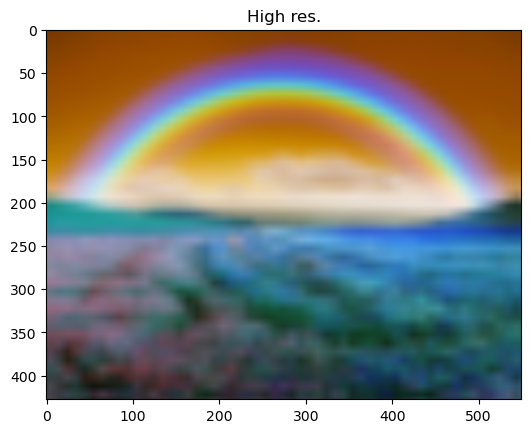

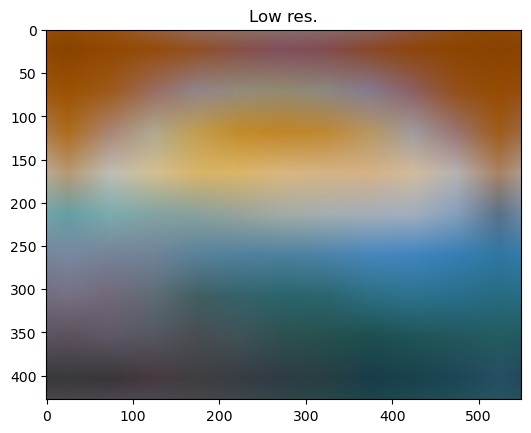

Combined accuracy = 45.43%


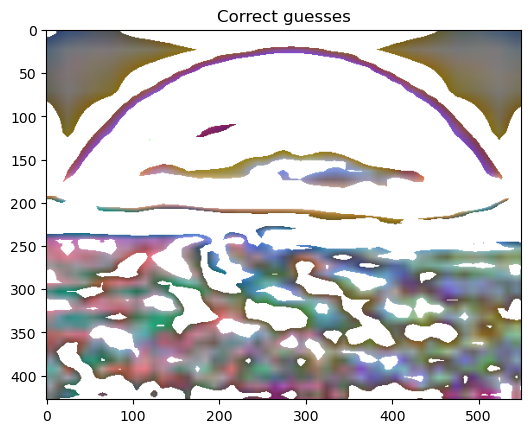

In [14]:
import numpy as np

def full_image_accuracy_2d(high_res_img: np.ndarray, low_res_img: np.ndarray, gamma: float = 1/255):
    """
    Expects a high resolution image (larger dimensions) and low resolution image (smaller dimensions) of the same size. 
    Compares all pixels within the image and checks if their average color scale difference is within gamma.

    Args:
        high_res_img, low_res_img - same size 2d arrays to compare values of. Both images should be normalized to [0,1]
        gamma - used as a margin of error. By default gamma is set to 1/255 in expectation of a [0,1] normalized color scale.

    Returns:
        combined_accuracy - accuracy of all pixels, regardless of class
        scale_match_masked - a 2d array displaying predictions sufficiently close to the label. 
                             a filler of 1 is used for incorrect predictions.
                             values are renormalized which causes increased contrast compared to the input images.
    """
    eps = 10**-12
    scale_match = high_res_img - low_res_img
    mask = np.where(np.abs(scale_match).mean(axis=-1) < gamma) # average absolute difference
    scale_match_masked = np.ones_like(scale_match) # zero difference indicates equality
    scale_match_masked[mask] = (scale_match[mask] - scale_match[mask].min()) / (scale_match[mask].max() - scale_match[mask].min() + eps) # keep interval [0,1]

    combined_accuracy = (scale_match_masked != 1).mean()

    return combined_accuracy, scale_match_masked

dims = img.shape[:-1]
high_res_img = scale_resolution_2d(img, 0.1, *dims)
low_res_img = scale_resolution_2d(high_res_img, 0.02, *dims)

plt.imshow(high_res_img)
plt.title("High res.")
plt.show()
plt.imshow(low_res_img)
plt.title("Low res.")
plt.show()

combined_accuracy, scale_match_masked = full_image_accuracy_2d(high_res_img, low_res_img, gamma=15/255)
print(f"Combined accuracy = {combined_accuracy * 100:.2f}%")
plt.imshow(scale_match_masked)
plt.title("Correct guesses")
plt.show()

In [ ]:
def shrub_only_accuracy(label_img: np.ndarray, preds: list):
    """
    Finds the accuracy of individual shrub predictions. For full image predictions use full_image_accuracy_2d() instead for vectorized operations.

    Args:
        label_img - np array representing 2d binary image.
        preds - list containing elements of the form (bool pred, int x, int y) where x,y are relative to the label image dimensions

    Ex. (2d)
    samp_img = np.array([
        [1,0],
        [0,0]
    ])
    samp_preds = [(1,0,0), (0,0,1), (1,1,1)]

    shrub_only_accuracy_2d(samp_img, samp_preds)

    Output:
    0.6666666666666666

    Ex. (3d)
    samp_img = np.array([
        [[1,0,0],
        [0,0,1]],
        [[1,1,0],
        [0,1,1]],
    ])
    samp_preds = [(1,0,0,0), (0,0,1,0), (1,1,1,0), (0,1,0,1), (0,0,1,1)]

    shrub_only_accuracy_2d(samp_img, samp_preds)

    Output:
    0.6
    """
    if len(preds) == 0:
        return None
    
    n_correct = 0
    for pred, *coords in preds:
        n_correct += pred == label_img[*coords]
    
    accuracy = n_correct / len(preds)
    return accuracy